In [153]:
import numpy as np 
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor,Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [154]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns = data.feature_names)
df["target"] = data.target

In [155]:
X = df.drop(columns=["target","sex"])
y =df["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state = 1)
#print(X_train)

In [156]:
#model = LinearRegression()
#model.fit(X_train,y_train)
model = Ridge(alpha=0.00001)

In [157]:
scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [158]:
model.fit(X_train_scaled, y_train)
#sgd.fit(X_train_scaled, y_train)

Ridge(alpha=1e-05)

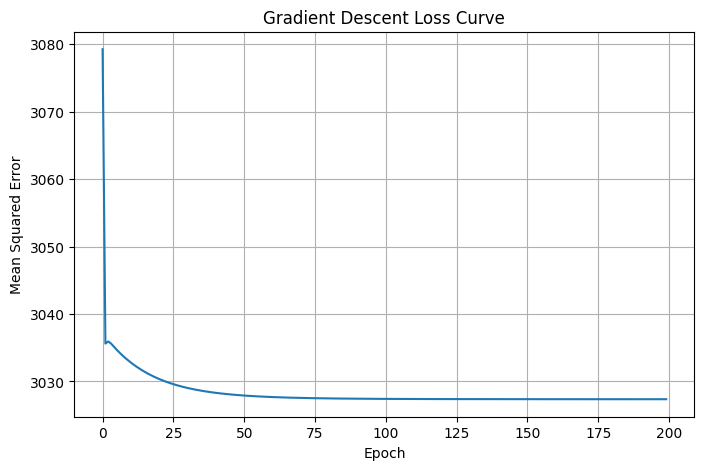

In [159]:
sgd =SGDRegressor(max_iter = 100000, alpha=0.0001, tol =1e-3,learning_rate= "adaptive", eta0=0.01, random_state=1,penalty="l2",)
#sgd.fit(X_train_scaled, y_train)
losses = []
# Train manually for many epochs
for epoch in range(200):

    sgd.partial_fit(X_train_scaled, y_train)

    y_pred_epoch = sgd.predict(X_train_scaled)

    mse = mean_squared_error(y_train, y_pred_epoch)

    losses.append(mse)

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Loss Curve")
plt.grid(True)
plt.show()

In [160]:
model_y_pred = model.predict(X_test_scaled)
sgd_y_pred = sgd.predict(X_test_scaled)
# Evaluate
print(f"R^2 Score for Ridge: {r2_score(y_test, model_y_pred):.4f}")
print(f"Mean Squared Error for Ridge: {mean_squared_error(y_test, model_y_pred):.4f}")

print(f"R^2 Score for SGD: {r2_score(y_test, sgd_y_pred):.4f}")
print(f"Mean Squared Error for SGD: {mean_squared_error(y_test, sgd_y_pred):.4f}")


R^2 Score for Ridge: 0.4426
Mean Squared Error for Ridge: 2970.3895
R^2 Score for SGD: 0.4310
Mean Squared Error for SGD: 3032.3292
